# SalesLens - Exploratory Data Analysis

This notebook answers business questions with the processed Olist data. It creates temporary analytical tables in memory only; it does not modify `data/raw/` or `data/processed/`.

## 1. Business Questions
- How large is the marketplace in orders, customers, products, sellers, items, product revenue, and freight?
- How do orders and product revenue evolve over time?
- Which categories, states, payment types, and sellers account for the largest observed activity?
- What delivery times are observed, and how are they associated with review scores?
- Which patterns require cautious interpretation because of data granularity or incomplete coverage?

## 2. Load Processed Data
Question: Which processed datasets and fields are available for analysis?

Dates are explicitly parsed on reload because CSV files store them as text.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
processed_dir = project_root / 'data' / 'processed'

orders = pd.read_csv(processed_dir / 'orders_clean.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
items = pd.read_csv(processed_dir / 'order_items_clean.csv', parse_dates=['shipping_limit_date'])
products = pd.read_csv(processed_dir / 'products_clean.csv')
customers = pd.read_csv(processed_dir / 'customers_clean.csv')
payments = pd.read_csv(processed_dir / 'order_payments_clean.csv')
reviews = pd.read_csv(processed_dir / 'order_reviews_clean.csv', parse_dates=['review_creation_date', 'review_answer_timestamp'])
sellers = pd.read_csv(processed_dir / 'sellers_clean.csv')

{name: df.shape for name, df in {'orders': orders, 'items': items, 'products': products, 'customers': customers, 'payments': payments, 'reviews': reviews, 'sellers': sellers}.items()}

{'orders': (99441, 8),
 'items': (112650, 7),
 'products': (32951, 10),
 'customers': (99441, 5),
 'payments': (103886, 5),
 'reviews': (99224, 7),
 'sellers': (3095, 4)}

### Analytical working tables
`item_fact` has one row per order item. It is appropriate for product revenue, freight, category volume, and seller volume. It must not be used to count orders without `nunique(order_id)`.

In [2]:
item_fact = (items
    .merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_delivered_customer_date']], on='order_id', how='inner')
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='left')
    .merge(products[['product_id', 'product_category_name', 'product_category_name_english']], on='product_id', how='left')
)
item_fact['category_display'] = item_fact['product_category_name_english'].fillna(item_fact['product_category_name']).fillna('Missing category')
item_fact['purchase_month'] = item_fact['order_purchase_timestamp'].dt.to_period('M').astype(str)
item_fact.shape

(112650, 16)

## 3. Sales Overview
Question: What is the observed commercial scale of the marketplace?

Definitions: product revenue is `sum(order_items.price)`; freight is `sum(order_items.freight_value)`; average basket is the mean product-value total per order with at least one item. Payment value is deliberately not used as revenue because it is a separate payment-level measure.

In [3]:
order_product_totals = items.groupby('order_id', as_index=False)['price'].sum()
kpis = pd.Series({
    'Orders': orders['order_id'].nunique(),
    'Unique customers': customers['customer_unique_id'].nunique(),
    'Products': products['product_id'].nunique(),
    'Sellers': sellers['seller_id'].nunique(),
    'Items sold': len(items),
    'Product revenue (BRL)': items['price'].sum(),
    'Freight value (BRL)': items['freight_value'].sum(),
    'Average basket - product value (BRL)': order_product_totals['price'].mean(),
})
kpis.to_frame('Value')

,Value
Orders,9.944100e+04
Unique customers,9.609600e+04
Products,3.295100e+04
Sellers,3.095000e+03
Items sold,1.126500e+05
Product revenue (BRL),1.359164e+07
Freight value (BRL),2.251910e+06
Average basket - product value (BRL),1.377541e+02


Interpretation: product revenue and freight are separate components. `payment_value` can differ from either because payments may include several payment records per order.

## 4. Sales Over Time
Question: How do order activity, product revenue, and average basket evolve by purchase month?

The calculation uses `order_purchase_timestamp` and item-level product prices. The partial months at the beginning and end of the dataset must not be treated as normal full months.

In [4]:
monthly = item_fact.groupby('purchase_month').agg(
    orders=('order_id', 'nunique'),
    product_revenue=('price', 'sum')
).reset_index()
monthly['average_basket'] = monthly['product_revenue'] / monthly['orders']
monthly['purchase_month'] = pd.to_datetime(monthly['purchase_month'])
monthly.head()

,purchase_month,orders,product_revenue,average_basket
0,2016-09-01,3,267.36,89.120000
1,2016-10-01,308,49507.66,160.739156
2,2016-12-01,1,10.90,10.900000
3,2017-01-01,789,120312.87,152.487795
4,2017-02-01,1733,247303.02,142.702262


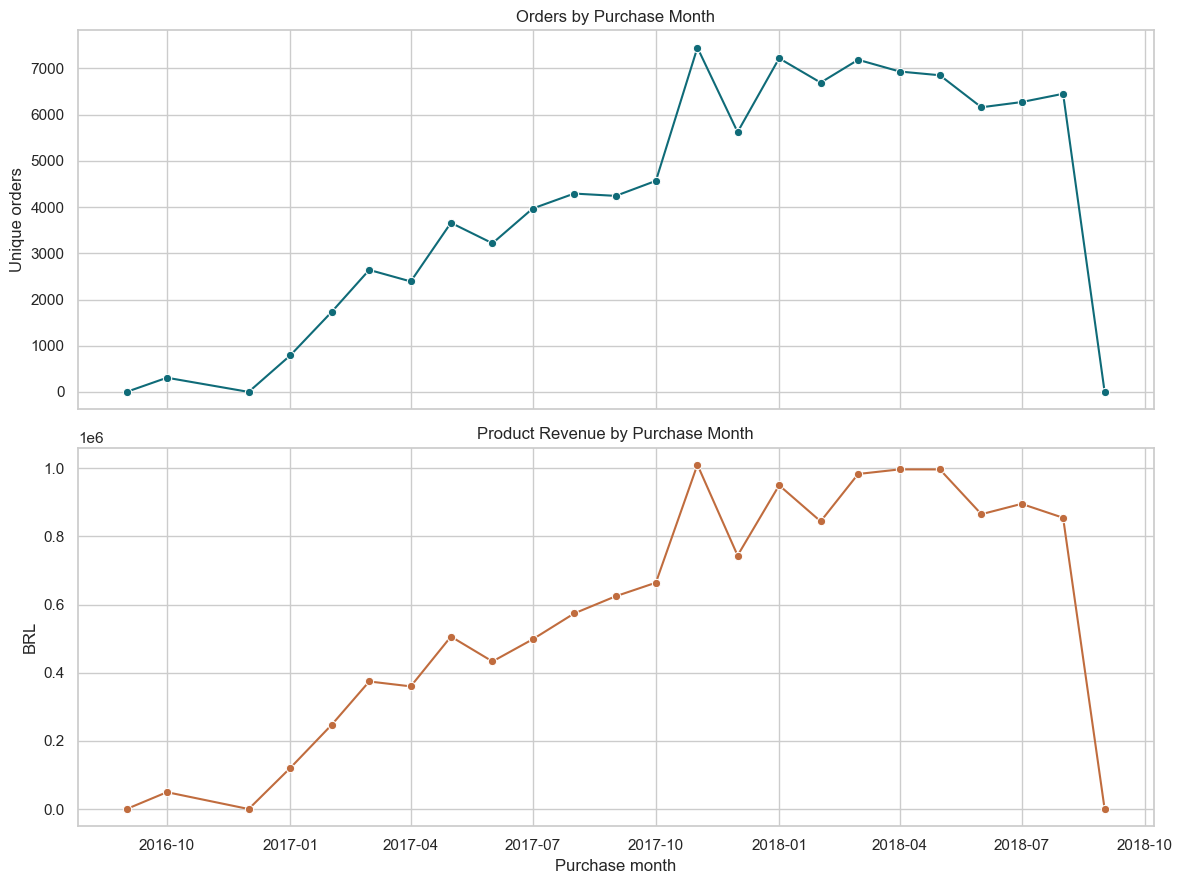

,purchase_month,orders,product_revenue,average_basket
13,2017-11-01 00:00:00,7451,1010271.37,135.588695


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
sns.lineplot(data=monthly, x='purchase_month', y='orders', marker='o', ax=axes[0], color='#0F6B78')
axes[0].set(title='Orders by Purchase Month', xlabel='', ylabel='Unique orders')
sns.lineplot(data=monthly, x='purchase_month', y='product_revenue', marker='o', ax=axes[1], color='#C06C3E')
axes[1].set(title='Product Revenue by Purchase Month', xlabel='Purchase month', ylabel='BRL')
plt.tight_layout()
plt.show()

monthly.loc[monthly['product_revenue'].idxmax()].to_frame().T

Limit: this period covers roughly two years, with incomplete edge months. It supports a trend description, not a confirmed seasonal pattern.

## 5. Product Analysis
Question: Which product categories generate the most item volume and product revenue, and why can the rankings differ?

Category labels use English when available, otherwise the original Portuguese category is shown. The original value remains unchanged in `products_clean.csv`.

In [6]:
category_summary = item_fact.groupby('category_display').agg(
    items_sold=('order_item_id', 'size'),
    product_revenue=('price', 'sum'),
    average_item_price=('price', 'mean')
).sort_values('product_revenue', ascending=False)
category_summary.head(10)

,items_sold,product_revenue,average_item_price
category_display,,,
health_beauty,9670,1258681.34,130.163531
watches_gifts,5991,1205005.68,201.135984
bed_bath_table,11115,1036988.68,93.296327
sports_leisure,8641,988048.97,114.344285
computers_accessories,7827,911954.32,116.513903
furniture_decor,8334,729762.49,87.564494
cool_stuff,3796,635290.85,167.357969
housewares,6964,632248.66,90.788148
auto,4235,592720.11,139.957523


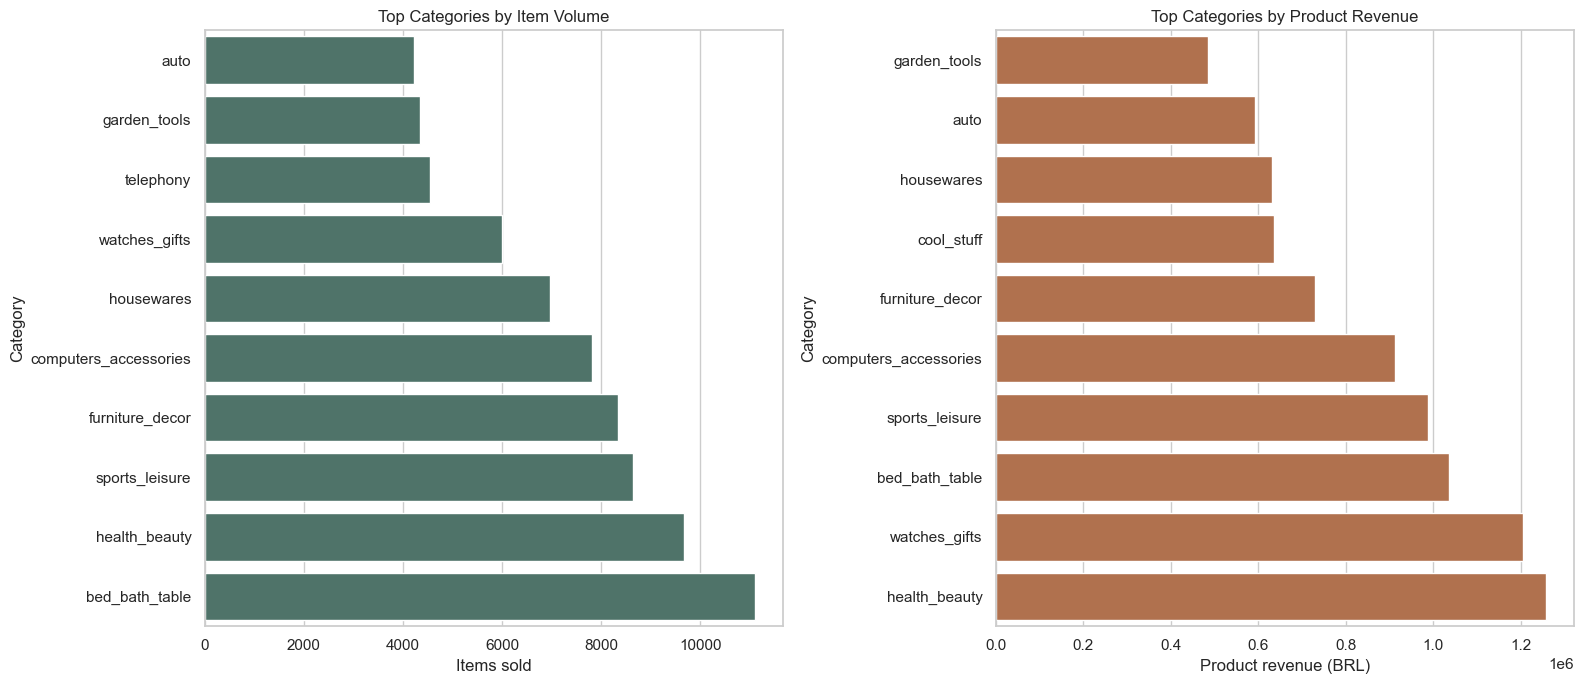

In [7]:
top_volume = category_summary.nlargest(10, 'items_sold').sort_values('items_sold')
top_revenue = category_summary.nlargest(10, 'product_revenue').sort_values('product_revenue')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=top_volume.reset_index(), x='items_sold', y='category_display', ax=axes[0], color='#49796B')
axes[0].set(title='Top Categories by Item Volume', xlabel='Items sold', ylabel='Category')
sns.barplot(data=top_revenue.reset_index(), x='product_revenue', y='category_display', ax=axes[1], color='#C06C3E')
axes[1].set(title='Top Categories by Product Revenue', xlabel='Product revenue (BRL)', ylabel='Category')
plt.tight_layout()
plt.show()

Interpretation: volume and revenue can diverge because categories have different average item prices. A category can sell fewer items while generating more revenue.

## 6. Customer Analysis
Question: Which customer states account for the largest number of observed orders and product revenue?

The state comes from the customer record associated with each order. This is a location distribution, not a measure of market potential.

In [8]:
state_summary = item_fact.groupby('customer_state').agg(
    customers=('customer_unique_id', 'nunique'),
    orders=('order_id', 'nunique'),
    product_revenue=('price', 'sum')
).sort_values('product_revenue', ascending=False)
state_summary.head(10)

,customers,orders,product_revenue
customer_state,,,
SP,39981,41375,5202955.05
RJ,12303,12762,1824092.67
MG,11178,11544,1585308.03
RS,5249,5432,750304.02
PR,4840,4998,683083.76
SC,3513,3612,520553.34
BA,3257,3358,511349.99
DF,2062,2125,302603.94
GO,1942,2007,294591.95


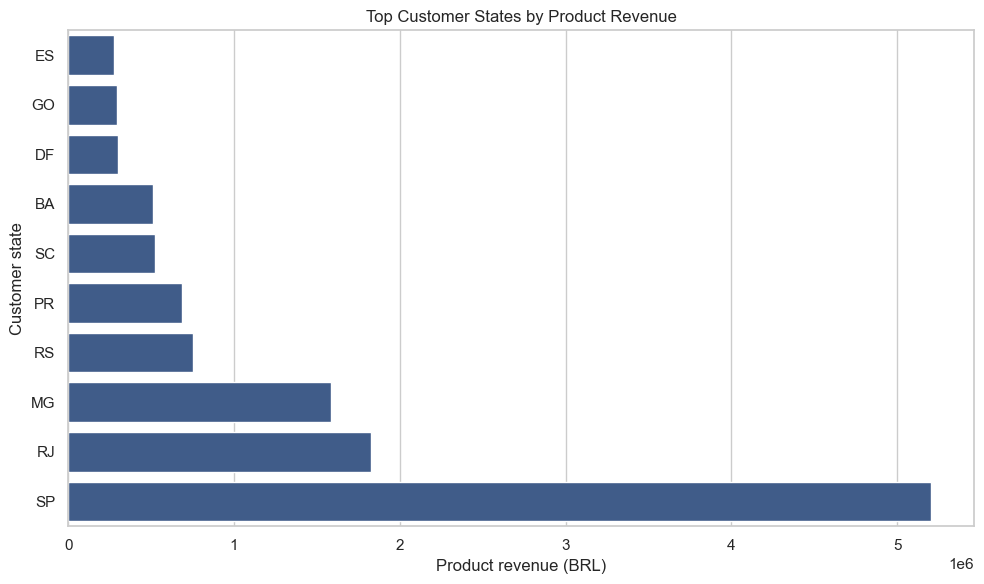

In [9]:
top_states = state_summary.head(10).sort_values('product_revenue')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_states.reset_index(), x='product_revenue', y='customer_state', color='#345995')
plt.title('Top Customer States by Product Revenue')
plt.xlabel('Product revenue (BRL)')
plt.ylabel('Customer state')
plt.tight_layout()
plt.show()

## 7. Payment Analysis
Question: Which payment methods account for transaction records, distinct orders, and recorded payment value?

`order_payments` is at payment-record granularity: an order may have multiple records. Therefore transaction count and distinct order count are both reported.

In [10]:
payment_summary = payments.groupby('payment_type').agg(
    payment_records=('payment_type', 'size'),
    distinct_orders=('order_id', 'nunique'),
    total_payment_value=('payment_value', 'sum'),
    average_payment_record=('payment_value', 'mean')
).sort_values('total_payment_value', ascending=False)
payment_summary

,payment_records,distinct_orders,total_payment_value,average_payment_record
payment_type,,,,
credit_card,76795,76505,12542084.19,163.319021
boleto,19784,19784,2869361.27,145.034435
voucher,5775,3866,379436.87,65.703354
debit_card,1529,1528,217989.79,142.570170
not_defined,3,3,0.00,0.000000


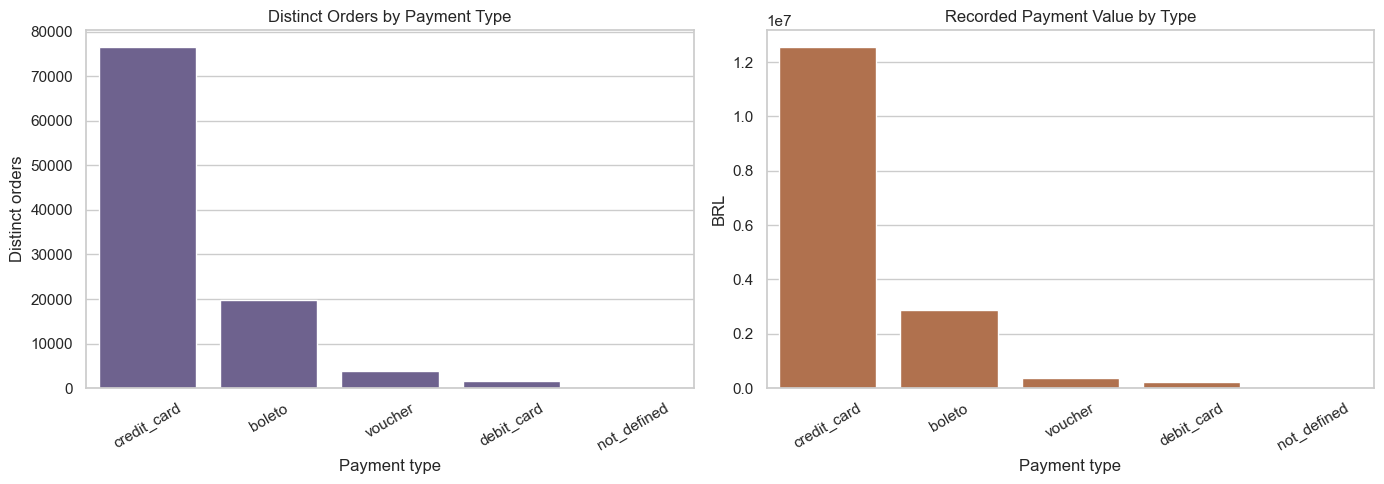

count    103886.000000
mean          2.853349
50%           1.000000
max          24.000000
Name: payment_installments, dtype: float64

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=payment_summary.reset_index(), x='payment_type', y='distinct_orders', ax=axes[0], color='#6B5B95')
axes[0].set(title='Distinct Orders by Payment Type', xlabel='Payment type', ylabel='Distinct orders')
sns.barplot(data=payment_summary.reset_index(), x='payment_type', y='total_payment_value', ax=axes[1], color='#C06C3E')
axes[1].set(title='Recorded Payment Value by Type', xlabel='Payment type', ylabel='BRL')
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

payments['payment_installments'].describe()[['count', 'mean', '50%', 'max']]

## 8. Delivery Analysis
Question: How long does delivery take for orders with both a purchase timestamp and a customer-delivery timestamp?

Missing delivery dates are excluded only from this delivery-time calculation. They are not filled or removed from the processed data.

In [12]:
delivery = orders.dropna(subset=['order_purchase_timestamp', 'order_delivered_customer_date']).copy()
delivery['delivery_days'] = (delivery['order_delivered_customer_date'] - delivery['order_purchase_timestamp']).dt.total_seconds() / 86400
delivery_stats = delivery['delivery_days'].agg(['count', 'mean', 'median', 'min', 'max'])
delivery_stats.to_frame('Delivery days')

,Delivery days
count,96476.000000
mean,12.558702
median,10.217755
min,0.533414
max,209.628611


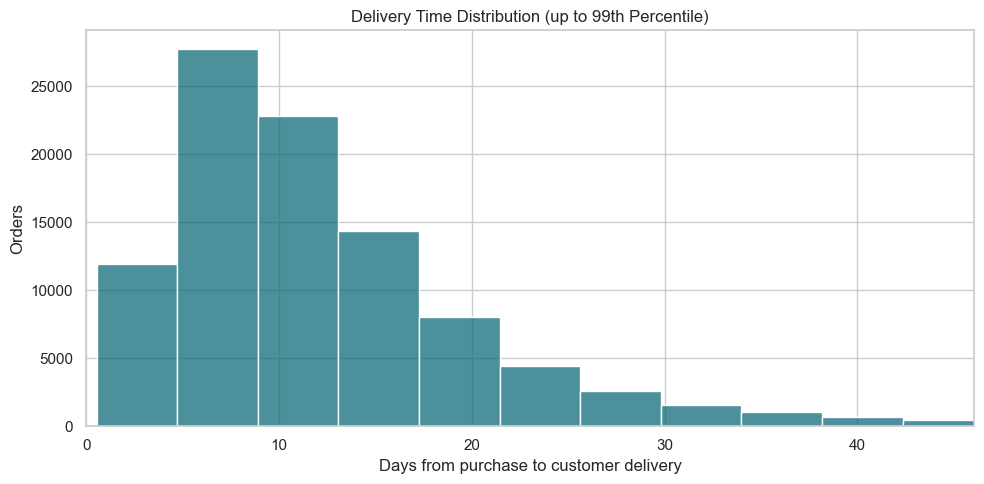

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(data=delivery, x='delivery_days', bins=50, color='#0F6B78')
plt.xlim(0, delivery['delivery_days'].quantile(0.99))
plt.title('Delivery Time Distribution (up to 99th Percentile)')
plt.xlabel('Days from purchase to customer delivery')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

Limit: the plot intentionally limits the x-axis to the 99th percentile to make the main distribution readable; the statistics still use all analysable deliveries.

## 9. Customer Satisfaction
Question: How are review scores distributed, and is delivery time associated with customer satisfaction?

Reviews are first aggregated to one mean score per order because an order can have more than one review record. This avoids duplicating delivery observations.

In [14]:
review_by_order = reviews.groupby('order_id', as_index=False).agg(review_score=('review_score', 'mean'))
satisfaction = delivery.merge(review_by_order, on='order_id', how='inner')
review_stats = reviews['review_score'].agg(['count', 'mean', 'median'])
relationship = satisfaction[['delivery_days', 'review_score']].corr().iloc[0, 1]
review_stats.to_frame('Review score'), relationship

(        Review score
 count   99224.000000
 mean        4.086421
 median      5.000000,
 np.float64(-0.3343017220365596))

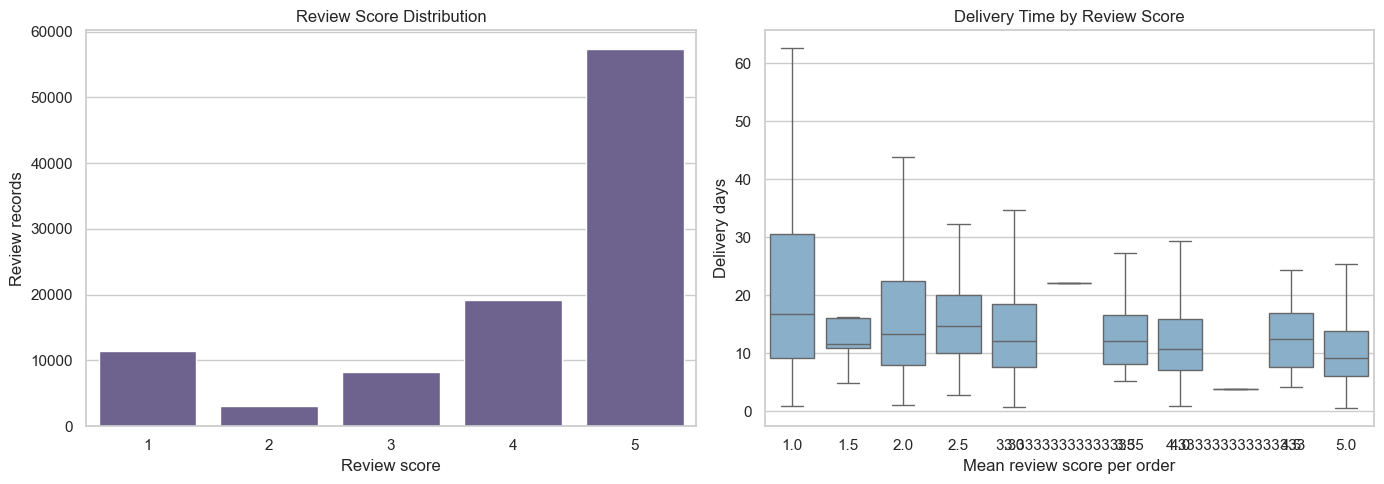

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=reviews, x='review_score', ax=axes[0], color='#6B5B95')
axes[0].set(title='Review Score Distribution', xlabel='Review score', ylabel='Review records')
sns.boxplot(data=satisfaction, x='review_score', y='delivery_days', ax=axes[1], color='#80B1D3', showfliers=False)
axes[1].set(title='Delivery Time by Review Score', xlabel='Mean review score per order', ylabel='Delivery days')
plt.tight_layout()
plt.show()

Interpretation: the observed correlation describes association, not causality. Review scores can also be affected by product quality, expectations, customer service, or other unobserved factors.

## 10. Seller Analysis
Question: Which sellers contribute the largest observed item volume, order reach, and product revenue?

This is an activity summary, not a complete performance ranking: it does not include margin, stock, returns, advertising, or seller service quality.

In [16]:
seller_summary = item_fact.groupby('seller_id').agg(
    items_sold=('order_item_id', 'size'),
    distinct_orders=('order_id', 'nunique'),
    product_revenue=('price', 'sum')
).sort_values('product_revenue', ascending=False)
seller_summary.head(10)

,items_sold,distinct_orders,product_revenue
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1156,1132,229472.63
53243585a1d6dc2643021fd1853d8905,410,358,222776.05
4a3ca9315b744ce9f8e9374361493884,1987,1806,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,586,585,194042.03
7c67e1448b00f6e969d365cea6b010ab,1364,982,187923.89
7e93a43ef30c4f03f38b393420bc753a,340,336,176431.87
da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,160236.57
7a67c85e85bb2ce8582c35f2203ad736,1171,1160,141745.53
1025f0e2d44d7041d6cf58b6550e0bfa,1428,915,138968.55


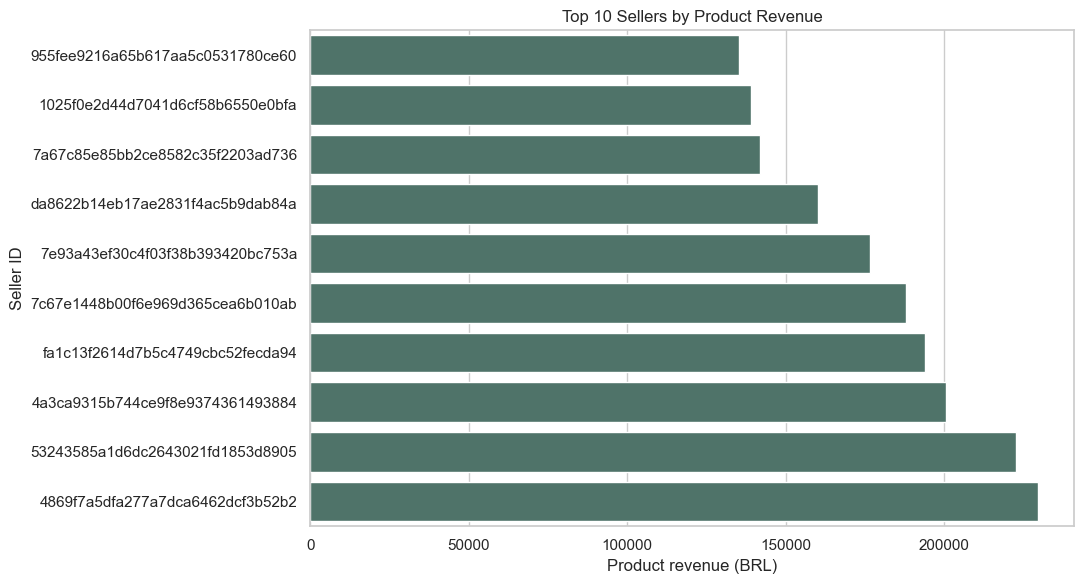

In [17]:
top_sellers = seller_summary.head(10).sort_values('product_revenue')
plt.figure(figsize=(11, 6))
sns.barplot(data=top_sellers.reset_index(), x='product_revenue', y='seller_id', color='#49796B')
plt.title('Top 10 Sellers by Product Revenue')
plt.xlabel('Product revenue (BRL)')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()

## 11. Relationships Between Variables
Question: How do category prices vary, and how does order volume relate to category revenue?

The charts use the top revenue categories so that comparisons remain readable.

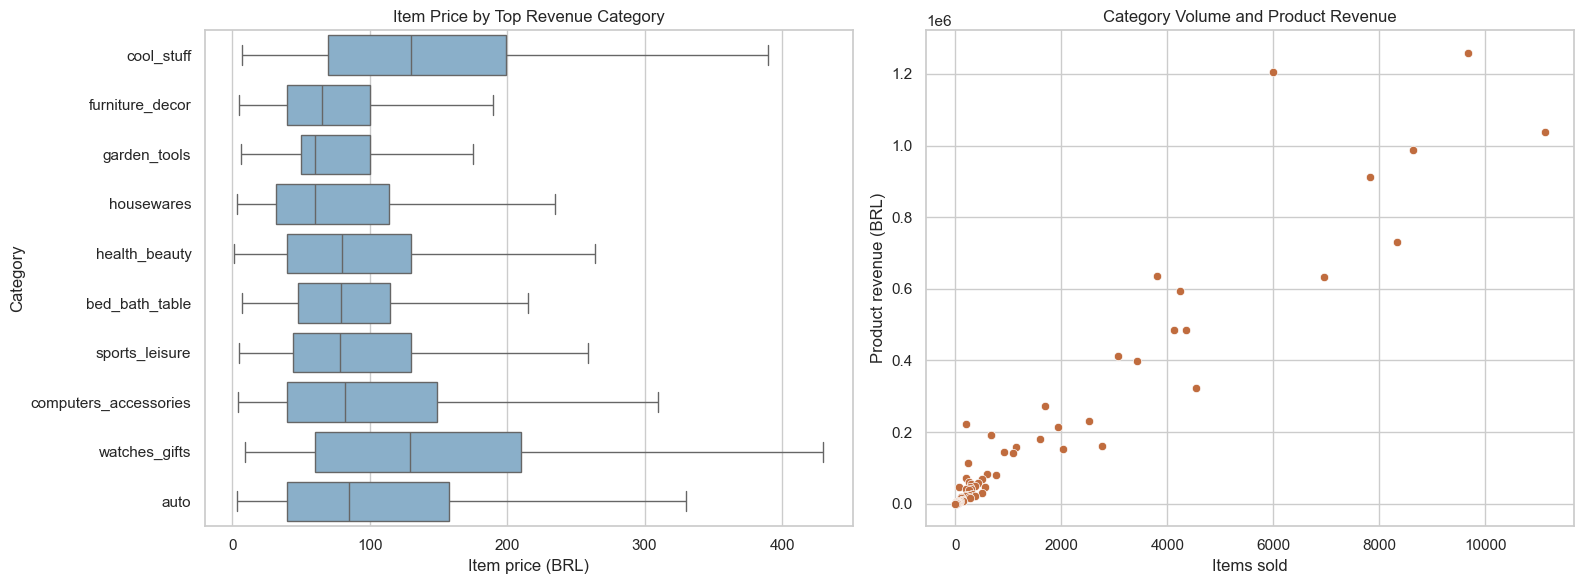

In [18]:
top_categories = category_summary.head(10).index
price_categories = item_fact[item_fact['category_display'].isin(top_categories)]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=price_categories, x='price', y='category_display', ax=axes[0], showfliers=False, color='#80B1D3')
axes[0].set(title='Item Price by Top Revenue Category', xlabel='Item price (BRL)', ylabel='Category')
sns.scatterplot(data=category_summary.reset_index(), x='items_sold', y='product_revenue', ax=axes[1], color='#C06C3E')
axes[1].set(title='Category Volume and Product Revenue', xlabel='Items sold', ylabel='Product revenue (BRL)')
plt.tight_layout()
plt.show()

Freight versus geographical distance is not analysed here. The available postal-code/geolocation data would require a defensible customer-to-seller location matching method; using raw coordinates without that method could mislead.

## 12. Initial Business Insights

### 1. Observation
The observed data contains 99,441 orders, 96,096 unique customers, 112,650 items, 32,951 products, and 3,095 sellers.

### Evidence
Product revenue is BRL 13.59M and observed freight is BRL 2.25M.

### Business Meaning
The marketplace has a broad catalogue and multi-seller structure.

### Limitation
Product revenue is not a profitability measure and excludes other commercial adjustments.

### 2. Observation
November 2017 is the highest observed product-revenue month, at about BRL 1.01M across 7,451 orders.

### Evidence
It is the maximum of the monthly product-revenue series.

### Business Meaning
It is a period worth investigating in later business analysis.

### Limitation
The data window is too short, and edge months are incomplete, to confirm seasonality.

### 3. Observation
`bed_bath_table` has the greatest item volume (11,115), while `health_beauty` has the highest product revenue (about BRL 1.26M).

### Evidence
The categories differ in average item price: about BRL 93 versus BRL 130.

### Business Meaning
High volume and high revenue are different commercial lenses.

### Limitation
This does not measure margin or product availability.

### 4. Observation
Sao Paulo (SP) is the largest customer state in the observed data, with 41,375 orders and about BRL 5.20M in product revenue.

### Evidence
SP leads the state-level order and revenue summaries.

### Business Meaning
Commercial activity is geographically concentrated in the observed customers.

### Limitation
Customer state is not a measurement of total addressable market.

### 5. Observation
Credit card is the largest recorded payment type, with 76,505 distinct orders and BRL 12.54M in payment value.

### Evidence
It exceeds the other payment types in both measures.

### Business Meaning
Payment mix is concentrated in one recorded payment method.

### Limitation
Payment rows are not identical to order rows because an order may have multiple payment records.

### 6. Observation
Among 96,476 orders with usable delivery dates, mean delivery time is 12.56 days and median delivery time is 10.22 days.

### Evidence
The mean exceeds the median, indicating a right-tailed delivery-time distribution.

### Business Meaning
A small set of long deliveries affects the average customer experience measure.

### Limitation
Orders without a delivery timestamp are excluded from this calculation.

### 7. Observation
Delivery time and average review score per order have a negative correlation of about -0.33.

### Evidence
Orders with score 1 average 21.34 delivery days, compared with 10.68 days for score 5.

### Business Meaning
Delivery experience is plausibly an important customer-satisfaction dimension to investigate.

### Limitation
This association does not establish that delivery time caused a review score.

### 8. Observation
The top seller by observed product revenue generated about BRL 229k, but another seller has the largest item volume among the top revenue group.

### Evidence
Seller rankings differ when sorted by item count versus revenue.

### Business Meaning
Seller activity should be assessed through more than one measure.

### Limitation
Revenue alone is not seller performance or profitability.

## 13. EDA Conclusion
This EDA establishes a business baseline using processed data: activity is concentrated by state, category, payment type, and seller; category volume differs from revenue; and longer delivery times are associated with lower review scores. These are evidence-backed observations for later modelling and BI work, not causal findings or recommendations.